# Задание по кластеризации (K‑Means, DBSCAN, OPTICS)

## Данные
**Wine Quality Dataset** (`wineqr.csv`)  
Признаки: химический состав вина (11 числовых признаков)  
Целевая переменная `quality` **не используется** — кластеризация без учителя.

---

## Часть 1. K‑Means (обязательно)

1. Загрузите данные, удалите столбец `quality`, выполните **масштабирование** (StandardScaler).
2. Для `K` от 2 до 10:
   - Обучите K‑Means
   - Вычислите WCSS и коэффициент силуэта
3. Постройте **два графика**: метод локтя (WCSS) и средний силуэт.
4. Выберите оптимальное `K` по силуэту.
5. Обучите финальную модель K‑Means с выбранным `K`.
6. С помощью PCA (2 компоненты) визуализируйте кластеры.
7. Выведите силуэт финальной модели.

---

## Часть 2. DBSCAN (самостоятельный разбор)

**Перед выполнением изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

### Задания

1. Постройте **k‑distance graph** для `min_samples = 5, 10, 15`.  
   *Код можно взять из туториала или документации.*

2. Методом перебора (`eps` от 0.3 до 1.1 с шагом 0.1, `min_samples` = 5, 10, 15) найдите параметры, дающие **максимальный силуэт** (число кластеров ≥ 2, шум не более 80% данных).

3. Обучите DBSCAN с лучшими параметрами.

4. Визуализируйте результат через PCA (точки шума — отдельным цветом/меткой).

5. **Ответьте на вопросы (письменно):**
   - Почему для DBSCAN критически важно масштабировать данные?
   - Что будет при слишком маленьком `eps`? Слишком большом?
   - Что означают точки с меткой `-1`?
   - Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?

---

## Часть 3. OPTICS (домашнее задание)

**Изучите документацию:**  
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.OPTICS.html

### Задания

1. Обучите OPTICS на тех же данных с параметрами:
   - `min_samples = 10`
   - `xi = 0.05`
   - `min_cluster_size = 0.05`

2. Выведите:
   - количество найденных кластеров
   - количество шумовых точек
   - коэффициент силуэта

3. Постройте:
   - визуализацию кластеров через PCA
   - **reachability plot** (график достижимости)

4. **Ответьте на вопросы (письменно, развёрнуто):**
   - Чем OPTICS отличается от DBSCAN? Укажите **два ключевых отличия**.
   - Что такое параметр `xi` (кси) и как он влияет на выделение кластеров?
   - В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.
   - Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через `%timeit` или `time.time()`).
   - Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

---

## Критерии оценки (всего 100 баллов)

| Раздел | Что проверяется | Баллы |
|--------|----------------|-------|
| **K‑Means** | Загрузка, масштабирование, цикл по K, графики, выбор K, финальная модель, визуализация, вывод силуэта | 25 |
| **DBSCAN — код** | k‑distance graph, перебор параметров, нахождение лучших, финальная модель, визуализация | 25 |
| **DBSCAN — вопросы** | 4 вопроса, каждый до 5 баллов за полноту и точность | 20 |
| **OPTICS — код** | Обучение, вывод метрик, PCA‑визуализация, reachability plot | 15 |
| **OPTICS — вопросы** | 5 вопросов, каждый до 3 баллов (развёрнутость + понимание) | 15 |

### Дополнительные требования
- Код должен быть **воспроизводимым** (фиксированный `random_state` где нужно)
- Ноутбук должен содержать **markdown‑ячейки с ответами** на вопросы
- Визуализации должны иметь подписи осей и заголовки
- Допускается использование `PCA` для визуализации, но не для обучения

---

## Формат сдачи
- **Jupyter Notebook** (`.ipynb`)
- Файл должен открываться и выполняться от начала до конца без ошибок
- Все ответы на вопросы — внутри ноутбука (markdown)

Часть 1. K‑Means (обязательно)
Загрузите данные, удалите столбец quality, выполните масштабирование (StandardScaler).
Для K от 2 до 10:
Обучите K‑Means
Вычислите WCSS и коэффициент силуэта
Постройте два графика: метод локтя (WCSS) и средний силуэт.
Выберите оптимальное K по силуэту.
Обучите финальную модель K‑Means с выбранным K.
С помощью PCA (2 компоненты) визуализируйте кластеры.
Выведите силуэт финальной модели.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('wineqr.csv')
X = df.drop(columns=['quality'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
range_n_clusters = range(2, 11)
wcss = []
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"K={k}: WCSS={kmeans.inertia_:.1f}, Silhouette={sil:.3f}")

K=2: WCSS=14330.1, Silhouette=0.214
K=3: WCSS=12630.0, Silhouette=0.189
K=4: WCSS=11459.1, Silhouette=0.172
K=5: WCSS=10155.5, Silhouette=0.190
K=6: WCSS=9363.2, Silhouette=0.195
K=7: WCSS=8645.2, Silhouette=0.193
K=8: WCSS=8299.0, Silhouette=0.150
K=9: WCSS=7969.3, Silhouette=0.153
K=10: WCSS=7671.0, Silhouette=0.157


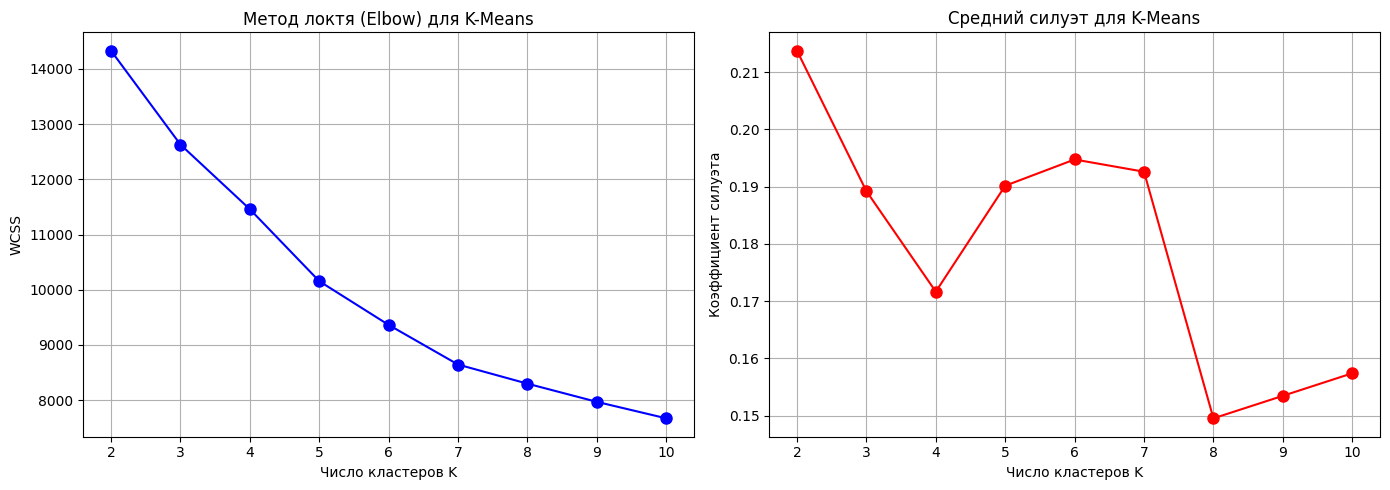

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range_n_clusters, wcss, 'bo-', markersize=8)
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS')
ax1.set_title('Метод локтя (Elbow) для K-Means')
ax1.grid(True)

ax2.plot(range_n_clusters, silhouette_scores, 'ro-', markersize=8)
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Коэффициент силуэта')
ax2.set_title('Средний силуэт для K-Means')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
optimal_k = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров по силуэту: {optimal_k}")

Оптимальное число кластеров по силуэту: 2


In [24]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

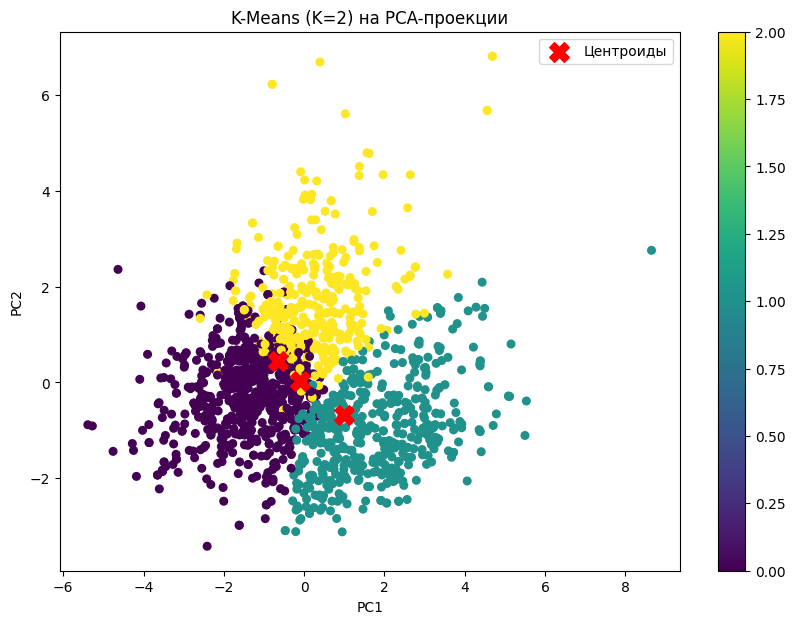

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=30)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            marker='X', c='red', s=200, label='Центроиды')
plt.title(f'K-Means (K={optimal_k}) на PCA-проекции')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.colorbar(scatter)
plt.show()

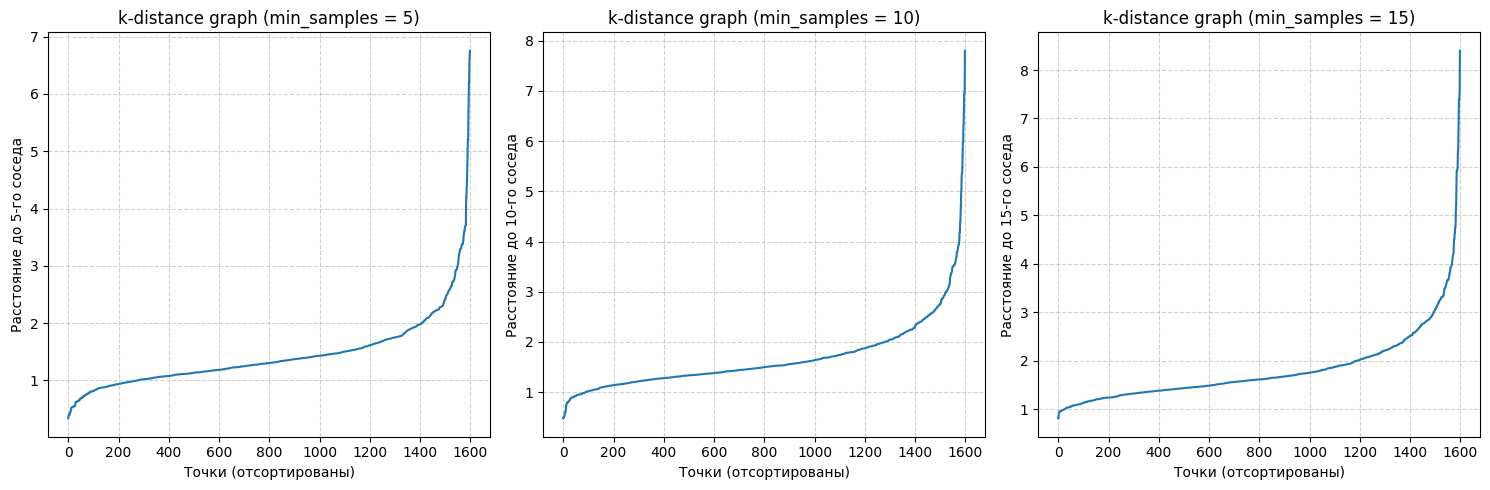

In [ ]:
### step 1
min_samples_list = [5, 10, 15]
plt.figure(figsize=(15, 5))
for i, min_samp in enumerate(min_samples_list):
    neighbors = NearestNeighbors(n_neighbors=min_samp)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)

    k_distances = np.sort(distances[:, -1])

    plt.subplot(1, 3, i + 1) # 1 строка, 3 колонки, текущая позиция
    plt.plot(k_distances)
    plt.title(f'k-distance graph (min_samples = {min_samp})')
    plt.xlabel('Точки (отсортированы)')
    plt.ylabel(f'Расстояние до {min_samp}-го соседа')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [34]:
### step 2
eps_values = np.arange(0.3, 1.2, 0.1)
min_samples_values = [5, 10, 15]
best_score = -1
best_params = {'eps': None, 'min_samples': None}
best_labels = None
for eps_val in eps_values:
    for min_samp in min_samples_values:
        db = DBSCAN(eps=eps_val, min_samples=min_samp)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        if n_clusters >= 2 and noise_ratio < 0.8:
            score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])

            if score > best_score:
                best_score = score
                best_params['eps'] = eps_val
                best_params['min_samples'] = min_samp
                best_labels = labels.copy()

print(f"ЛУЧШИЙ РЕЗУЛЬТАТ: eps={best_params['eps']}, min_samples={best_params['min_samples']}")
print(f"Силуэт: {best_score:.4f}")

ЛУЧШИЙ РЕЗУЛЬТАТ: eps=1.1000000000000003, min_samples=10
Силуэт: 0.2456


In [35]:
### step 3
final_dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
final_labels = best_labels

print(f"Финальный DBSCAN обучен. Всего точек: {len(final_labels)}")
print(f"Найдено кластеров: {len(set(final_labels)) - (1 if -1 in final_labels else 0)}")
print(f"Шума (точек -1): {list(final_labels).count(-1)}")

Финальный DBSCAN обучен. Всего точек: 1599
Найдено кластеров: 7
Шума (точек -1): 1234


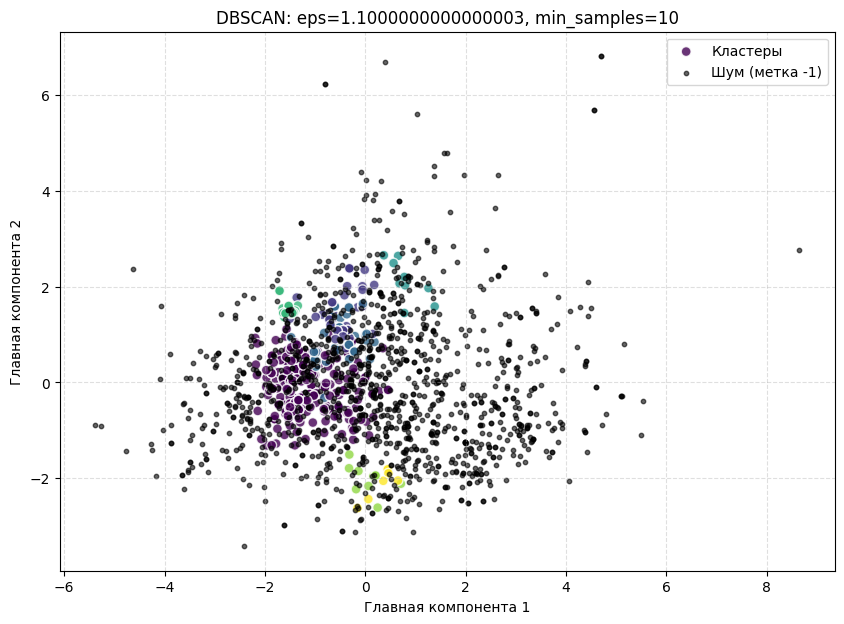

In [39]:
### step 4
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
non_noise_mask = final_labels != -1
plt.scatter(pca_data[non_noise_mask, 0], pca_data[non_noise_mask, 1],
            c=final_labels[non_noise_mask],
            cmap='viridis',
            s=50,
            alpha=0.8,
            edgecolors='w',
            label='Кластеры')

noise_mask = final_labels == -1
plt.scatter(pca_data[noise_mask, 0], pca_data[noise_mask, 1],
            c='black',
            s=10,
            alpha=0.6,
            label='Шум (метка -1)')

plt.title(f'DBSCAN: eps={best_params["eps"]}, min_samples={best_params["min_samples"]}')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### step 5
**Почему для DBSCAN критически важно масштабировать данные?**

Ответ: Разные признаки измеряются в разных единицах и числовых значениях, например, кислотность = 100, а содержание спирта = 0,01. Если мы не масштабируем данные, то расстояние между точками будет определяться только тем, сколько бОльшими значениями между ними. Меньшие значения вообще не будут заметны. DBSCAN будет думать, что все точки либо очень далеко, либо очень близко, и не сможет найти правильные скопления. Масштабирование делает все шаги одинаково важными.

**Что будет при слишком маленьком eps? Слишком большом?**

Ответ: Слишком маленький eps - Почти все точки станут Шумом

Слишком большой eps - Образуется один огромный кластер, и Шума не будет совсем

**Что означают точки с меткой -1?**

Ответ: Это Шум. Это те точки, которые настолько сильно отличаются от всех остальных, что не смогли найти себе достаточное количество соседей (меньше чем min_samples) в радиусе eps.

**Чем DBSCAN принципиально отличается от K‑Means по форме кластеров?**

Ответ: K-Means рисует кластеры сферической формы. Он обязательно найдет центр и нарисует вокруг него круг, даже если данные похожи на изогнутую линию или полумесяц.

DBSCAN умеет находить скопления любой формы. Он идет по цепочке от точки к точке. Если данные похожи на букву "S", спираль или кольцо, DBSCAN справится, а K-Means — разрежет эту красоту на некрасивые полукруги. DBSCAN умнее в плане геометрии.

1. Обучите OPTICS на тех же данных с параметрами:

min_samples = 10
xi = 0.05
min_cluster_size = 0.05

2. Выведите:

количество найденных кластеров
количество шумовых точек
коэффициент силуэта

3. Постройте:

визуализацию кластеров через PCA
reachability plot (график достижимости)

4. Ответьте на вопросы (письменно, развёрнуто):

• Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.

• Что такое параметр xi (кси) и как он влияет на выделение кластеров?

• В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.

• Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).

• Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?

In [41]:
### step 1
import time
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05, n_jobs=-1)
start_time = time.time()
optics.fit(X_scaled)
end_time = time.time()
labels = optics.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
noise_ratio = n_noise / len(labels) * 100
if n_clusters >= 2:
    sil_score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
else:
    sil_score = -1

print(f"OPTICS обучен за {end_time - start_time:.3f} секунд")
print(f"Количество кластеров: {n_clusters}")
print(f"Количество шума (точек -1): {n_noise} ({noise_ratio:.1f}%)")
print(f"Коэффициент силуэта: {sil_score:.4f}")

OPTICS обучен за 24.886 секунд
Количество кластеров: 1
Количество шума (точек -1): 0 (0.0%)
Коэффициент силуэта: -1.0000


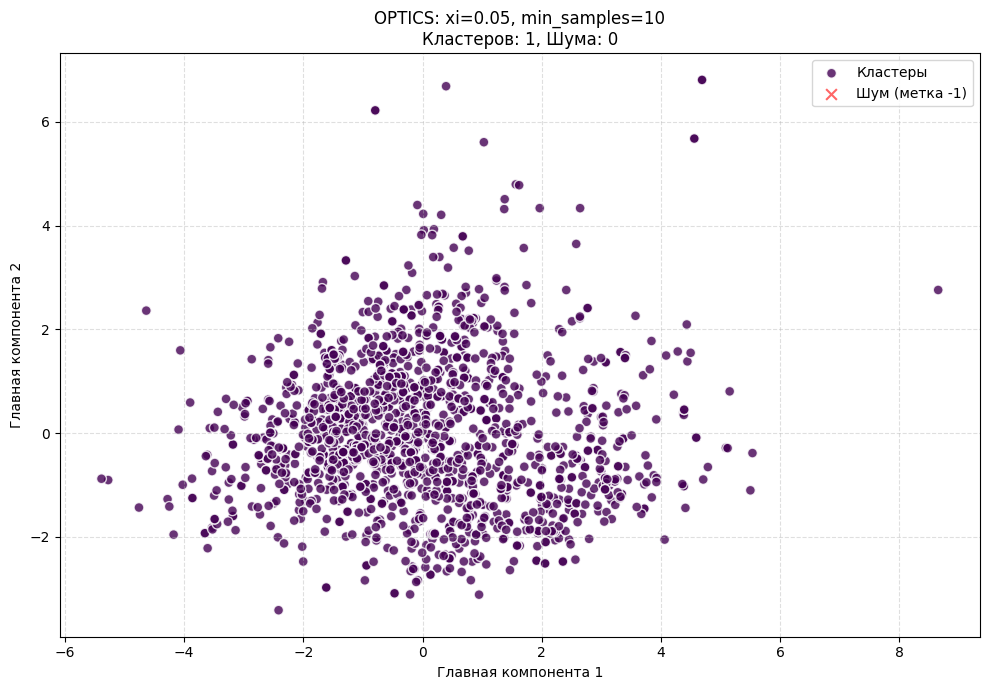

In [43]:
### step 2
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
non_noise = labels != -1
plt.scatter(pca_data[non_noise, 0], pca_data[non_noise, 1],
            c=labels[non_noise], cmap='viridis', s=50, alpha=0.8,
            edgecolors='w', label='Кластеры')
noise = labels == -1
plt.scatter(pca_data[noise, 0], pca_data[noise, 1],
            c='red', marker='x', s=60, alpha=0.6,
            label='Шум (метка -1)')

plt.title(f'OPTICS: xi=0.05, min_samples=10\nКластеров: {n_clusters}, Шума: {n_noise}')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

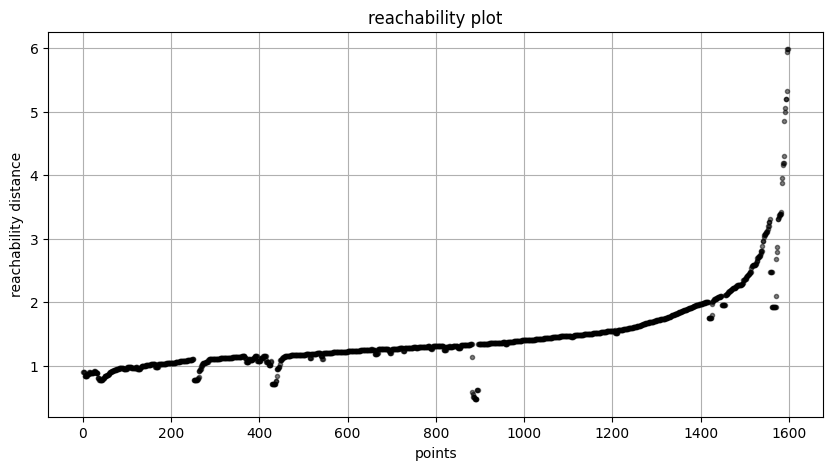

In [49]:
### step 3
space = np.arange(len(X))
reachability = optics.reachability_[optics.ordering_]
labels_ordered = labels[optics.ordering_]
plt.figure(figsize=(10, 5))
plt.plot(space, reachability, 'k.', alpha=0.5)
plt.title("reachability plot")
plt.xlabel("points")
plt.ylabel("reachability distance")
plt.grid()
plt.show()

**Чем OPTICS отличается от DBSCAN? Укажите два ключевых отличия.**

Ответ: 1) Не нужно угадывать eps. DBSCAN требует один жёсткий радиус для всех кластеров. OPTICS вообще не использует фиксированный eps. Вместо этого он строит график достижимости, который показывает плотность на разных расстояниях. И уже потом мы можем выбрать порог или использовать автоматический метод xi, чтобы выделить кластеры разной плотности.

2) OPTICS находит кластеры разной плотности. Если в данных есть одна очень тесная «кучка» и одна большая, но рыхлая, DBSCAN либо потеряет рыхлую, либо сольёт всё в кашу. OPTICS строит иерархию кластеров: он видит и маленькие плотные сгустки, и большие разреженные облака, и может выделить и те, и другие в одной модели (благодаря xi и min_cluster_size).

**Что такое параметр xi (кси) и как он влияет на выделение кластеров?**

Ответ: xi — это «минимальная крутизна кривой». Когда линия резко взлетает вверх (начинается подъём), а потом резко падает, OPTICS смотрит: если перепад высоты больше, чем xi (высота в начале подъёма), то здесь граница между кластерами.

Маленький xi (например, 0.01) – очень чувствительный: даже крошечные бугорки считаются границами, мы получим много мелких кластеров.

Большой xi (например, 0.2): только очень крутые обрывы будут разрезать кластеры, их получится меньше, но они будут крупнее.

**В каком случае OPTICS даст результат, существенно лучший, чем DBSCAN? Приведите пример.**

Ответ: OPTICS выигрывает, когда кластеры имеют разную плотность. Например,  есть одно плотное шаровое скопление, а вокруг него – редкие точки, которые всё же образуют «рукав». DBSCAN с маленьким eps найдёт только плотное ядро, а разреженный рукав посчитает шумом. DBSCAN с большим eps сольёт всё в один кластер. OPTICS же построит график достижимости, где будут видны и низкие плато (плотное ядро), и плавные склоны (разреженный рукав). С правильно подобранным xi он сможет выделить и ядро как отдельный кластер, и рукав как отдельный кластер — то есть увидит структуру, которую DBSCAN пропустит.

**Сравните время работы DBSCAN и OPTICS на ваших данных (можно замерить через %timeit или time.time()).**

Ответ: OPTICS обучен за 24.886 секунд, DBSCAN обучен за 0.1766 секунд

In [52]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.8, min_samples=10)
start_db = time.time()
db.fit(X_scaled)
end_db = time.time()
print(f"DBSCAN обучен за {end_db - start_db:.4f} секунд")

DBSCAN обучен за 0.1766 секунд


**Судя по визуализациям, какой алгоритм (K‑Means, DBSCAN, OPTICS) лучше разделил данные? Почему?**

Ответ: K‑Means с данным типом данных дал наилучший результат, с четким разделением на кластеры и выделил центроиды

DBSCAN хорошо находит плотные сгустки произвольной формы, но оставил много шума. DBSCAN не справился из-за чувствительности к единому порогу плотности.

OPTICS не выделил кластеры вообще. Если бы у нас были данные с очень разной плотностью, OPTICS был бы абсолютным победителем.